In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import openpyxl

file = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh1_results.xlsx"


In [18]:
# =========================
# KIES HIER DE MATRIXTERM Aij
# =========================
row_dof = "surge"   # opties: surge, sway, heave, roll, pitch, yaw
col_dof = "surge"   # opties: surge, sway, heave, roll, pitch, yaw

# =========================
# MAPPING
# =========================
dof_to_index = {
    "surge": 0,
    "sway": 1,
    "heave": 2,
    "roll": 3,
    "pitch": 4,
    "yaw": 5,
}

excel_col_map = {
    "surge": 2,  # B
    "sway": 3,   # C
    "heave": 4,  # D
    "roll": 5,   # E
    "pitch": 6,  # F
    "yaw": 7,    # G
}

excel_row_offset_map = {
    "surge": 5,  # eerste matrixrij
    "sway": 6,
    "heave": 7,
    "roll": 8,
    "pitch": 9,
    "yaw": 10,
}

if row_dof not in dof_to_index:
    raise ValueError(f"Onbekende row_dof '{row_dof}'")
if col_dof not in dof_to_index:
    raise ValueError(f"Onbekende col_dof '{col_dof}'")

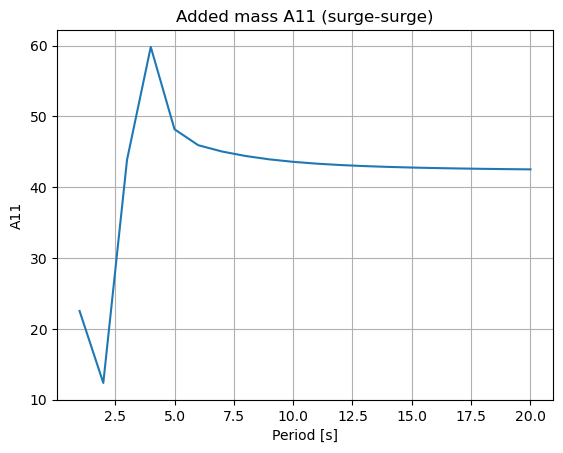

In [19]:


i = dof_to_index[row_dof] + 1
j = dof_to_index[col_dof] + 1

row_offset = excel_row_offset_map[row_dof]
col = excel_col_map[col_dof]

y_label = f"A{i}{j}"
plot_title = f"Added mass {y_label} ({row_dof}-{col_dof})"

# =========================
# EXCEL INLEZEN
# =========================
wb = openpyxl.load_workbook(file, data_only=True)
ws = wb["Added mass"]

periods = []
values = []

for r in range(1, ws.max_row + 1):
    cell_value = ws.cell(r, 2).value  # kolom B

    if isinstance(cell_value, str) and "Added mass for period" in cell_value:
        m = re.search(r"period\s+([\d,\.]+)s", cell_value)
        if m:
            T = float(m.group(1).replace(",", "."))
            value = ws.cell(r + row_offset, col).value

            periods.append(T)
            values.append(value if value is not None else np.nan)

periods = np.array(periods, dtype=float)
values = np.array(values, dtype=float)

# sorteren
idx = np.argsort(periods)
periods = periods[idx]
values = values[idx]

# print("Periods:", periods)
# print(f"{y_label}:", values)

# =========================
# PLOT VS PERIODE
# =========================
plt.figure()
# plt.plot(periods, values, marker="o")
plt.plot(periods, values)
plt.xlabel("Period [s]")
plt.ylabel(y_label)
plt.title(plot_title)
plt.grid(True)
plt.show()

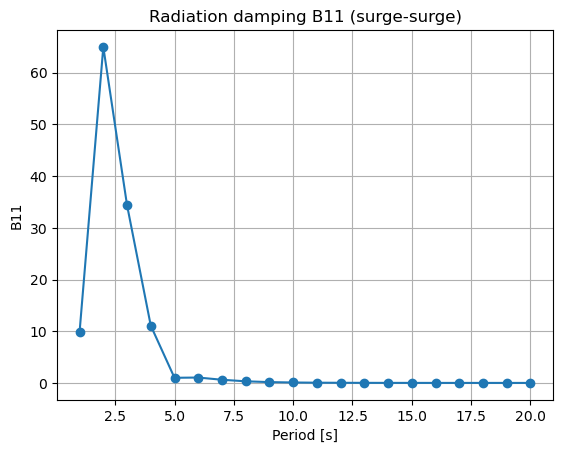

In [20]:


i = dof_to_index[row_dof] + 1
j = dof_to_index[col_dof] + 1

row_offset = excel_row_offset_map[row_dof]
col = excel_col_map[col_dof]

y_label = f"B{i}{j}"
plot_title = f"Radiation damping {y_label} ({row_dof}-{col_dof})"

# =========================
# EXCEL INLEZEN
# =========================
wb = openpyxl.load_workbook(file, data_only=True)
ws = wb["Damping"]

periods = []
values = []

for r in range(1, ws.max_row + 1):
    cell_value = ws.cell(r, 2).value  # kolom B

    if isinstance(cell_value, str) and "Damping for period" in cell_value:
        m = re.search(r"period\s+([\d,\.]+)s", cell_value)
        if m:
            T = float(m.group(1).replace(",", "."))
            value = ws.cell(r + row_offset, col).value

            periods.append(T)
            values.append(value if value is not None else np.nan)

periods = np.array(periods, dtype=float)
values = np.array(values, dtype=float)

# sorteren
idx = np.argsort(periods)
periods = periods[idx]
values = values[idx]

# print("Periods:", periods)
# print(f"{y_label}:", values)

# =========================
# PLOT VS PERIODE
# =========================
plt.figure()
plt.plot(periods, values, marker="o")
plt.xlabel("Period [s]")
plt.ylabel(y_label)
plt.title(plot_title)
plt.grid(True)
plt.show()